<a href="https://colab.research.google.com/github/sofiasanvi/PRO1/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Card

### The paper:
*Eukaryotic plankton diversity in the sunlit ocean*

### The data object:
OTU occurrence data from Tara Oceans samples. The dataset contains the abundance of different Operational Taxonomic Units (OTUs) across samples.

### The random variable chosen:
The number of OTUs present in a sample (OTU richness). An OTU is considered present when its abundance is greater than zero.

### What the paper does:
The Tara Oceans project investigates the diversity and distribution of marine microorganisms across different ocean environments. The published data contains information about the occurrence and abundance of OTUs in samples collected from different locations.

### The generative model proposed:
We model the number of OTUs observed in a sample using a negative binomial distribution:

$$
X \sim NB(n,p)
$$

where $X$ represents the OTU richness of a sample.

We chose the negative binomial distribution because the observed variance in OTU richness is much larger than the observed mean, indicating overdispersion. A Poisson model, where the mean and variance are equal, would therefore not describe the observed variation well.

### Parameters and assumptions:
The model has two dimensionless parameters, $n$ and $p$. The parameter $n$ affects the shape and dispersion of the distribution, while $p$ affects the expected OTU richness and variance. For a fixed $n$, a higher $p$ gives a lower expected OTU richness. The random variable $X$ is measured as the number of OTUs per sample.

The model assumes that:
- OTU richness can be represented by a negative binomial distribution.
- Each sample is treated as an independent observation.
- The samples can be described by the same underlying distribution, even though they originate from different environments and locations.
- An OTU is considered present when its abundance is greater than zero.

### The forward simulation:
Using the estimated parameters $n$ and $p$, we generate simulated OTU richness values from the negative binomial distribution. The simulated distribution is then compared with the observed OTU richness distribution.

### The parameterization/fitting:
The parameters are estimated from the observed mean $\mu$ and variance $\sigma^2$ of OTU richness:

$$
n = \frac{\mu^2}{\sigma^2-\mu}
$$

$$
p = \frac{n}{n+\mu}
$$

We also use non-parametric bootstrapping to investigate the uncertainty of the estimated parameter $p$. The observed samples are resampled with replacement and the parameters are recalculated for each bootstrap sample.

### What/if the model adds to the paper:
The model provides a simple statistical description of the variation in OTU richness between Tara Oceans samples. It allows us to generate new simulated observations and quantify the uncertainty of the estimated model parameter.

### Model limitations/how it breaks:
The negative binomial distribution accounts for overdispersion in OTU richness across samples, which may arise from differences in environmental conditions.

However, the model does not explicitly include environmental factors or locations. Therefore, it can describe the overall variation in OTU richness but cannot explain the biological mechanisms causing these differences.

The model may also be less accurate for specific environments if their OTU richness distributions differ substantially from the overall distribution.

In [ ]:
import csv
import matplotlib.pyplot as plt
import statistics
import numpy as np

In the code below, we import the data. The dataset contains different samples with their corresponding OTUs and the abundance of each OTU. From this data, we calculate how many different OTUs are present in each sample. If the abundance of an OTU is 0, it is not counted as present. The total number of OTUs for each sample is then stored in a dictionary. Finally, the values from the dictionary are plotted in a histogram to visualize the distribution of OTU richness across the samples.


{'TARA_N000000077': 938, 'TARA_A100001640': 3857, 'TARA_N000000835': 1776, 'TARA_N000000827': 6465, 'TARA_N000000839': 2762, 'TARA_N000000845': 1126, 'TARA_N000000837': 4085, 'TARA_N000000829': 7602, 'TARA_N000000833': 8045, 'TARA_N000000841': 2185, 'TARA_A100000402': 938, 'TARA_A100001646': 1660, 'TARA_A100000394': 2056, 'TARA_A100000393': 5924, 'TARA_A100000400': 2114, 'TARA_E500000200': 1455, 'TARA_A100000398': 1898, 'TARA_A100000396': 7791, 'TARA_E500000196': 3273, 'TARA_N000001664': 1520, 'TARA_N000001654': 3565, 'TARA_N000001646': 5254, 'TARA_N000001650': 5843, 'TARA_N000001658': 3505, 'TARA_N000001656': 3007, 'TARA_N000001648': 3713, 'TARA_N000001652': 4268, 'TARA_N000001660': 1510, 'TARA_A100000546': 934, 'TARA_A100000553': 3573, 'TARA_A100000551': 6900, 'TARA_A100001333': 6370, 'TARA_A100000548': 3769, 'TARA_A100000554': 2812, 'TARA_A100000558': 521, 'TARA_A100000559': 6969, 'TARA_A100000556': 1414, 'TARA_A100000594': 974, 'TARA_A100000598': 2985, 'TARA_A100000595': 5438, 'TAR

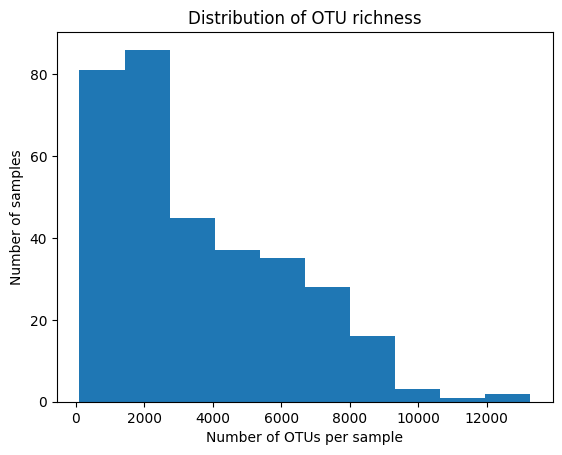

In [ ]:
filename = "Database_W5_OTU_occurences.tsv"

with open(filename, "r", encoding="utf-8") as file:
    reader = csv.DictReader(file, delimiter="\t")

    sample_columns = []

    for column in reader.fieldnames:
        if column.startswith("TARA_"):
            sample_columns.append(column)

    richness = {}

    for sample in sample_columns:
        richness[sample] = 0

    for row in reader:
        for sample in sample_columns:
            count = float(row[sample])

            if count > 0:
                richness[sample] += 1

print(richness)
print("Mean richness:", statistics.mean(richness.values()))
print("Variance in richness:", statistics.variance(richness.values()))
plt.hist(richness.values())
plt.title('Distribution of OTU richness')
plt.xlabel('Number of OTUs per sample')
plt.ylabel('Number of samples')
plt.show()

### Backward step: parameter estimation

In the backward step, we use the observed OTU richness data to estimate the parameters of the negative binomial model. We first calculate the observed mean and variance, and then use these values to estimate the parameters $n$ and $p$.

In [ ]:
values = np.array(list(richness.values()))

mean = np.mean(values)
variance = np.var(values, ddof=1)

n = mean**2 / (variance - mean)
p = n / (n + mean)

# Forward simulation

To simulate data from our model, we selected a negative binomial distribution. We first considered a Poisson distribution because the values we are working with are count data. However, a Poisson distribution assumes that the expected value and the variance are approximately equal, \(E[X] = Var(X)\). In our data, the variance was clearly larger than the mean, which indicates overdispersion.

One possible reason for this large variation is that the samples were collected from different ocean environments, where factors such as light, pH, depth, and ion concentrations may differ. Because the negative binomial distribution can account for greater variation than the Poisson distribution, we considered it a more suitable model for our data.

The negative binomial distribution has two parameters that control the mean and the amount of variation in the distribution. In the following code, we use the previously estimated parameters $n$ and $p$ to generate simulated OTU richness values from the negative binomial distribution and compare them with the observed data.


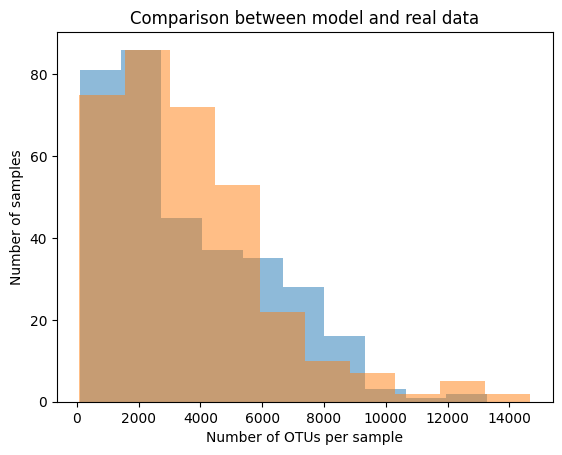

In [ ]:
random_nb = np.random.negative_binomial(n, p, size=len(values))

plt.hist(values, alpha=0.5, label="Observed")
plt.hist(random_nb, alpha=0.5, label="Negative binomial")
plt.title('Comparison between model and real data')
plt.xlabel('Number of OTUs per sample')
plt.ylabel('Number of samples')
plt.show()

# Uncertainty
To investigate the uncertainty of the estimated parameter $p$, non-parametric bootstrapping was used. This gives us insight into the stability and precision of the parameter estimate. The uncertainty was evaluated using the bootstrap standard error and a 95% confidence interval.

In [ ]:
n_bootstrap = 1000

bootstrap_n = []
bootstrap_p = []

for i in range(n_bootstrap):

    bootstrap_sample = np.random.choice(values,size=len(values),replace=True)
    bootstrap_mean = np.mean(bootstrap_sample)
    bootstrap_variance = np.var(bootstrap_sample, ddof=1)

    if bootstrap_variance > bootstrap_mean:
        n_boot = bootstrap_mean**2 / (bootstrap_variance - bootstrap_mean)
        p_boot = n_boot / (n_boot + bootstrap_mean)

        bootstrap_n.append(n_boot)
        bootstrap_p.append(p_boot)

se_p = np.std(bootstrap_p, ddof=1)
ci_p = np.percentile(bootstrap_p,[2.5, 97.5])

print("Original p:", p)
print("Bootstrap standard error:", se_p)
print("95% confidence interval:", ci_p)

Original p: 0.0005407954662466219
Bootstrap standard error: 3.349732572216798e-05
95% confidence interval: [0.00048234 0.00061189]


Original p: 0.0005407954662466219

Bootstrap standard error: 3.43904269485442e-05

95% confidence interval: [0.0004793  0.00061831]

The bootstrap results show that the estimate of $p$ is relatively stable. The standard error is small relative to the estimated value, and the 95% confidence interval ranges from approximately 0.00048 to 0.00062.